# Tải model MiDas v2.1 Small (.pth)

In [1]:
import os
import torch

print("Đang tải mô hình MiDaS v2.1 Small gốc...")
model = torch.hub.load("intel-isl/MiDaS", "MiDaS_small", pretrained=True)
model.eval()

save_path = os.path.join(os.getcwd(), "midas_v21_small.pth")
torch.save(model.state_dict(), save_path)
print(f"Đã lưu mô hình vào: {save_path}")

Đang tải mô hình MiDaS v2.1 Small gốc...


Using cache found in /Users/bach/.cache/torch/hub/intel-isl_MiDaS_master
/Users/bach/Downloads/AI Projects/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/bach/Downloads/AI Projects/.venv/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading weights:  None


Using cache found in /Users/bach/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master


Đã lưu mô hình vào: /Users/bach/Downloads/AI Projects/VEDC_2026/src/midas_v21_small.pth


# Import video MP4, ảnh và Resize

In [3]:
#Import video moving_cars.mp4
import cv2
cap = cv2.VideoCapture("moving_cars.mp4")
# Resize video to 256x256
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 256)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 256)
# Get video properties
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))


OpenCV: Couldn't read video stream from file "moving_cars.mp4"


Resized image shape: (256, 256, 3)


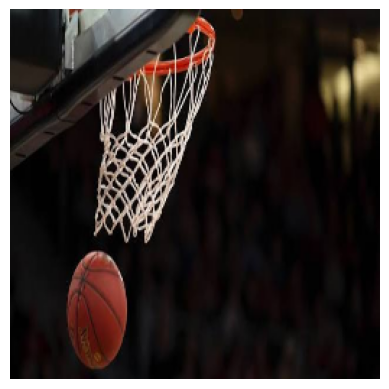

In [2]:
# Import image basketball.jpg and resize to 256x256
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("basketball.jpeg")
img_resized = cv2.resize(img, (256, 256))
print("Resized image shape:", img_resized.shape)

plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Đưa ảnh vào MiDas và xuất ra chỉ số Depth

Using cache found in /Users/bach/.cache/torch/hub/intel-isl_MiDaS_master
Using cache found in /Users/bach/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master


Loading weights:  None
5th percentile: 10.275617361068726, 95th percentile: 847.8805541992188


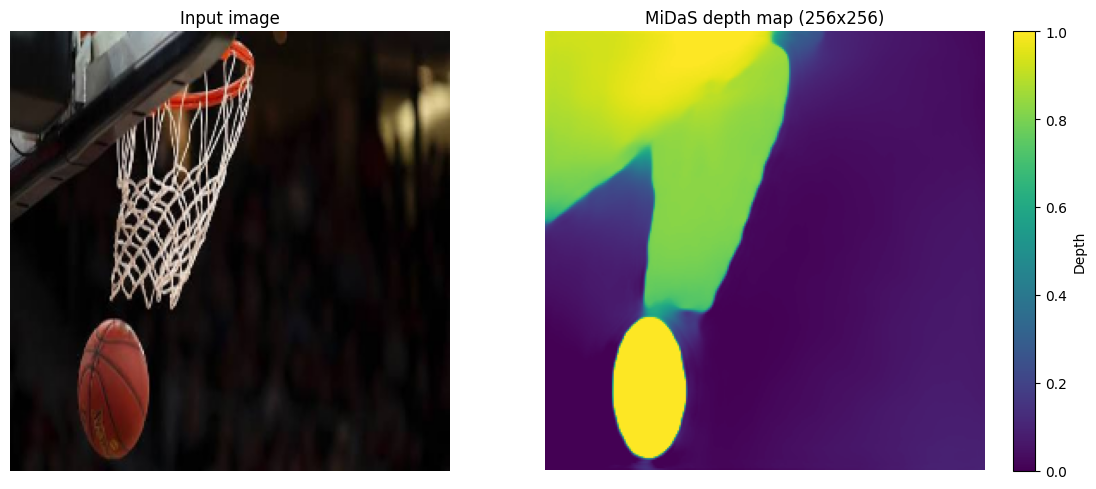

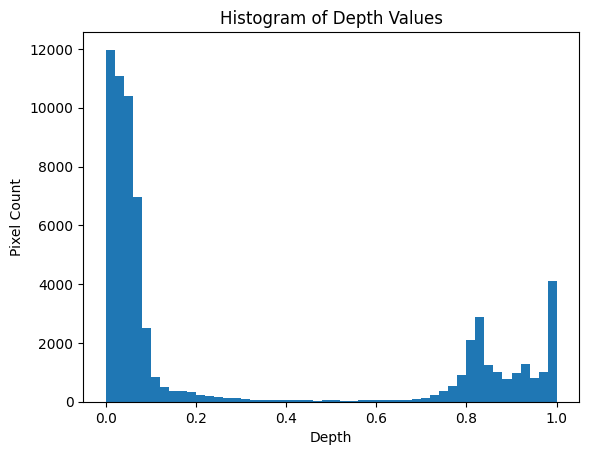

In [3]:
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from torchvision import transforms
import pandas as pd

# Load model weights from the saved .pth file
model_path = "midas_v21_small.pth"

# Load MiDaS small architecture
model = torch.hub.load("intel-isl/MiDaS", "MiDaS_small", pretrained=False)
model.load_state_dict(torch.load(model_path, map_location="cpu"))
model.eval()

# Preprocess for MiDaS small
midas_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Convert resized image to RGB and prepare input
img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
input_tensor = midas_transforms(img_rgb).unsqueeze(0)

with torch.no_grad():
    prediction = model(input_tensor)
    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img_resized.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze().cpu()

# Convert to numpy array with shape (256, 256)
raw_depth = prediction.numpy().astype(np.float32)
# Percentile normalization to [0, 1]
p5 = np.percentile(raw_depth,5)
p95 = np.percentile(raw_depth,95)
print(f"5th percentile: {p5}, 95th percentile: {p95}")  
depth_norm = np.clip(raw_depth,p5,p95)
depth_norm = (depth_norm-p5)/(p95-p5)

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Input image")

plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(depth_norm, cmap="viridis")
plt.colorbar(label="Depth")
plt.title("MiDaS depth map (256x256)")
plt.axis("off")
plt.tight_layout()
plt.show()
plt.hist(depth_norm.flatten(), bins=50)

plt.xlabel("Depth")
plt.ylabel("Pixel Count")
plt.title("Histogram of Depth Values")
plt.show()


# Tạo Risk Map

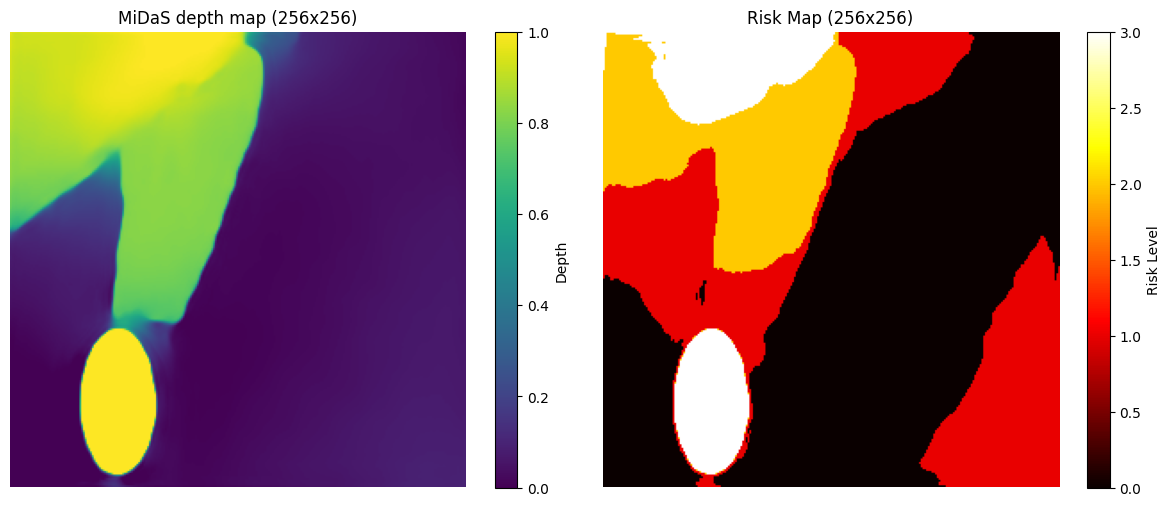

In [4]:
risk_map = np.zeros_like(depth_norm, dtype=np.uint8)
q50 = np.percentile(depth_norm,50)
q75 = np.percentile(depth_norm,75)
q90 = np.percentile(depth_norm,90)

#Assign risk levels based on depth percentiles
risk_map[depth_norm>q90]=3 
risk_map[(depth_norm>q75)&(depth_norm<=q90)] =2 
risk_map[(depth_norm>q50)&(depth_norm<=q75)] =1
risk_map[depth_norm<=q50] =0
# Visualize the risk map using matplotlib
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(depth_norm, cmap="viridis")
plt.colorbar(label="Depth")
plt.title("MiDaS depth map (256x256)")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(risk_map, cmap="hot", vmin=0, vmax=3)
plt.colorbar(label="Risk Level")
plt.title("Risk Map (256x256)")
plt.axis("off")
plt.tight_layout()
plt.show()


# Thực hiện Path Planning